### **Cargar señal ECG (2da derivación)**
#### **Señal ECG - Post ejercicio**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, welch, spectrogram
import pywt

# Parámetros del BITalino
Fs = 1000         # Hz
VCC = 3.3         # V referencia ADC
ADCres = 1023     # 10 bits
GAIN_ECG = 1100   # ganancia

# Carga y conversión ADC -> mV
ecg_adc = np.loadtxt("Señales/ecg_ejercicio.txt", usecols=[-1])
ecg_V  = ((ecg_adc / ADCres) - 0.5) * VCC / GAIN_ECG
ecg_mV = ecg_V * 1000 

# Intervalo de muestra de interés: 5.7 a 8.7 seg (post ejercicio)
i0, i1 = int(5.7*Fs), int(8.7*Fs)
x  = ecg_mV[i0:i1]
t  = np.arange(i0, i1) / Fs

# Eliminar componente DC
x = x - np.mean(x)

# Filtro: pasa-banda (0.5 – 40 Hz)
b_bp, a_bp = butter(4, [0.5/(Fs/2), 40/(Fs/2)], btype="band")
x_bp = filtfilt(b_bp, a_bp, x)

# Filtro: notch (60 Hz)
b_n, a_n = iirnotch(60, Q=30, fs=Fs)  # red de 60 Hz
x_filt = filtfilt(b_n, a_n, x_bp)

#### **Señal ECG - Reposo**

In [2]:
# Carga y conversión ADC -> mV
ecg_adc2 = np.loadtxt("Señales/ecg_reposo_inicial.txt", usecols=[-1])
ecg_V2  = ((ecg_adc2 / ADCres) - 0.5) * VCC / GAIN_ECG
ecg_mV2 = ecg_V2 * 1000

# Intervalo de muestra de interés: 5 a 8 seg (reposo)
i2, i3 = int(5*Fs), int(8*Fs)
x2  = ecg_mV2[i2:i3]
t2  = np.arange(i2, i3) / Fs

# Eliminar componente DC
x2 = x2 - np.mean(x2)

# Filtro: pasa-banda (0.5 – 40 Hz)
b2_bp, a_bp = butter(4, [0.5/(Fs/2), 40/(Fs/2)], btype="band")
x2_bp = filtfilt(b2_bp, a_bp, x2)

# Filtro: notch (60 Hz)
b2_n, a2_n = iirnotch(60, Q=30, fs=Fs)  # red de 60 Hz
x2_filt = filtfilt(b2_n, a2_n, x2_bp)

### **Aplicar DWT a señal ECG**

In [3]:
# Aplicar la DWT a señal ECG - post ejercicio
niveles = 4
coeficientes = pywt.wavedec(x_filt, 'db4', level=niveles)

# Reconstruir la señal a partir de los coeficientes de aproximación
# Establecer un umbral para el denoising
umbral = 0.1

# Aplicar el umbral a los coeficientes
coeffs_umbral = [pywt.threshold(c, umbral, mode='soft') for c in coeficientes]

# Reconstruir la señal denoised
x_rec = pywt.waverec(coeffs_umbral, 'db4')

In [4]:
# Aplicar la DWT a señal ECG - reposo
niveles2 = 4
coeficientes2 = pywt.wavedec(x2_filt, 'db6', level=niveles2)

# Reconstruir la señal a partir de los coeficientes de aproximación
# Establecer un umbral para el denoising
umbral2 = 0.1

# Aplicar el umbral a los coeficientes
coeffs_umbral2 = [pywt.threshold(c, umbral2, mode='soft') for c in coeficientes2]

# Reconstruir la señal denoised
x_rec2 = pywt.waverec(coeffs_umbral2, 'db6')

### **Graficar la señal original y los coeficientes de detalle y de aproximación**

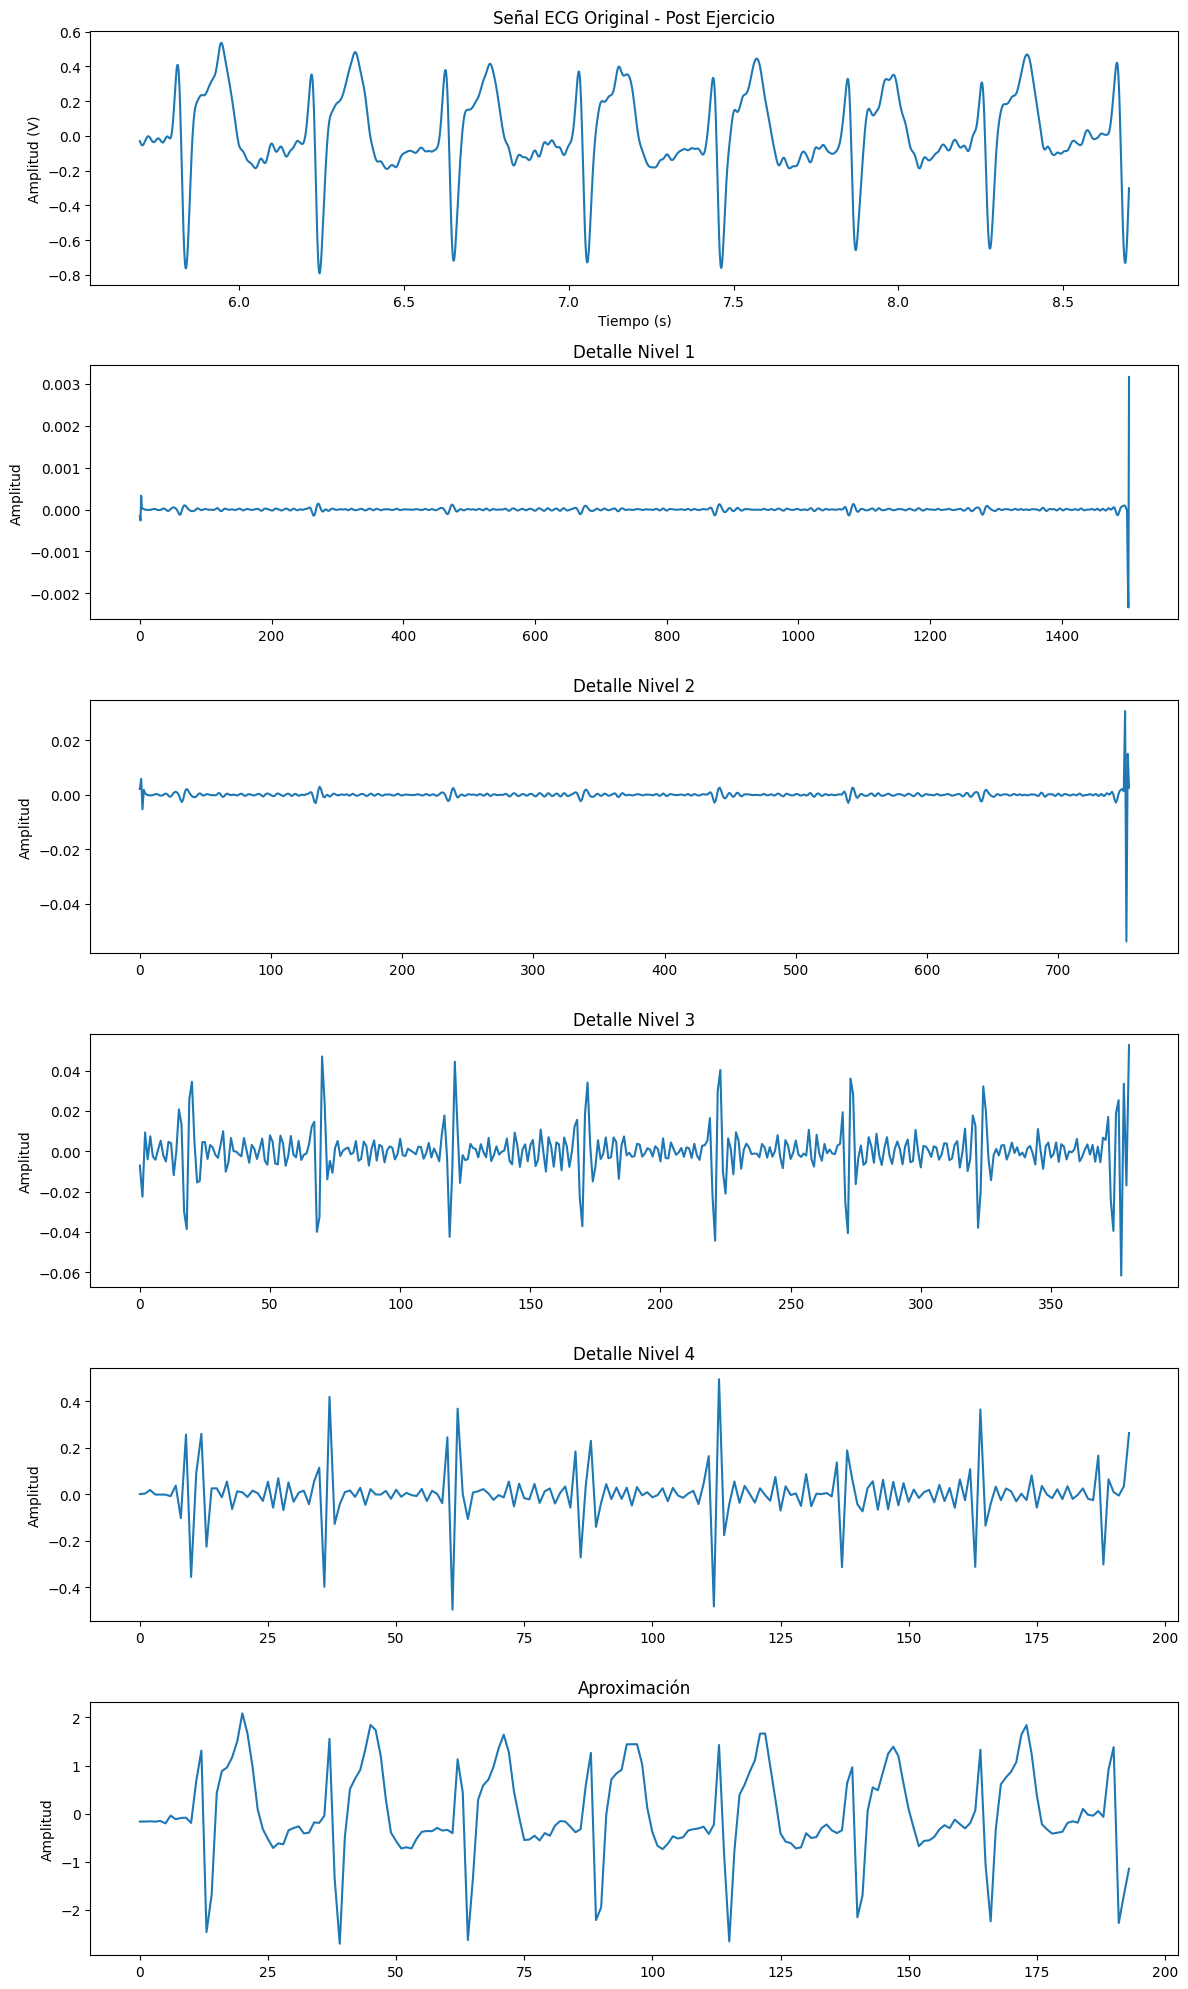

In [5]:
# Graficar la señal original - Post ejercicio y los coeficientes de detalle y de aproximación
plt.figure(figsize=(12, 20))

# Graficar la señal original
plt.subplot(niveles + 2, 1, 1)
plt.plot(t, x_filt)
plt.title('Señal ECG Original - Post Ejercicio')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')

# Graficar los coeficientes de detalle en orden ascendente
for i in range(1, niveles + 1):
    plt.subplot(niveles + 2, 1, i + 1)
    plt.plot(coeficientes[niveles - i + 1])
    plt.title(f'Detalle Nivel {i}')
    plt.ylabel('Amplitud')

# Graficar el coeficiente de aproximación al final
plt.subplot(niveles + 2, 1, niveles + 2)
plt.plot(coeficientes[0])
plt.title('Aproximación')
plt.ylabel('Amplitud')

plt.tight_layout()
plt.show()

### **Graficar la señal original y reconstruida**
#### **Señal ECG - Post ejercicio**

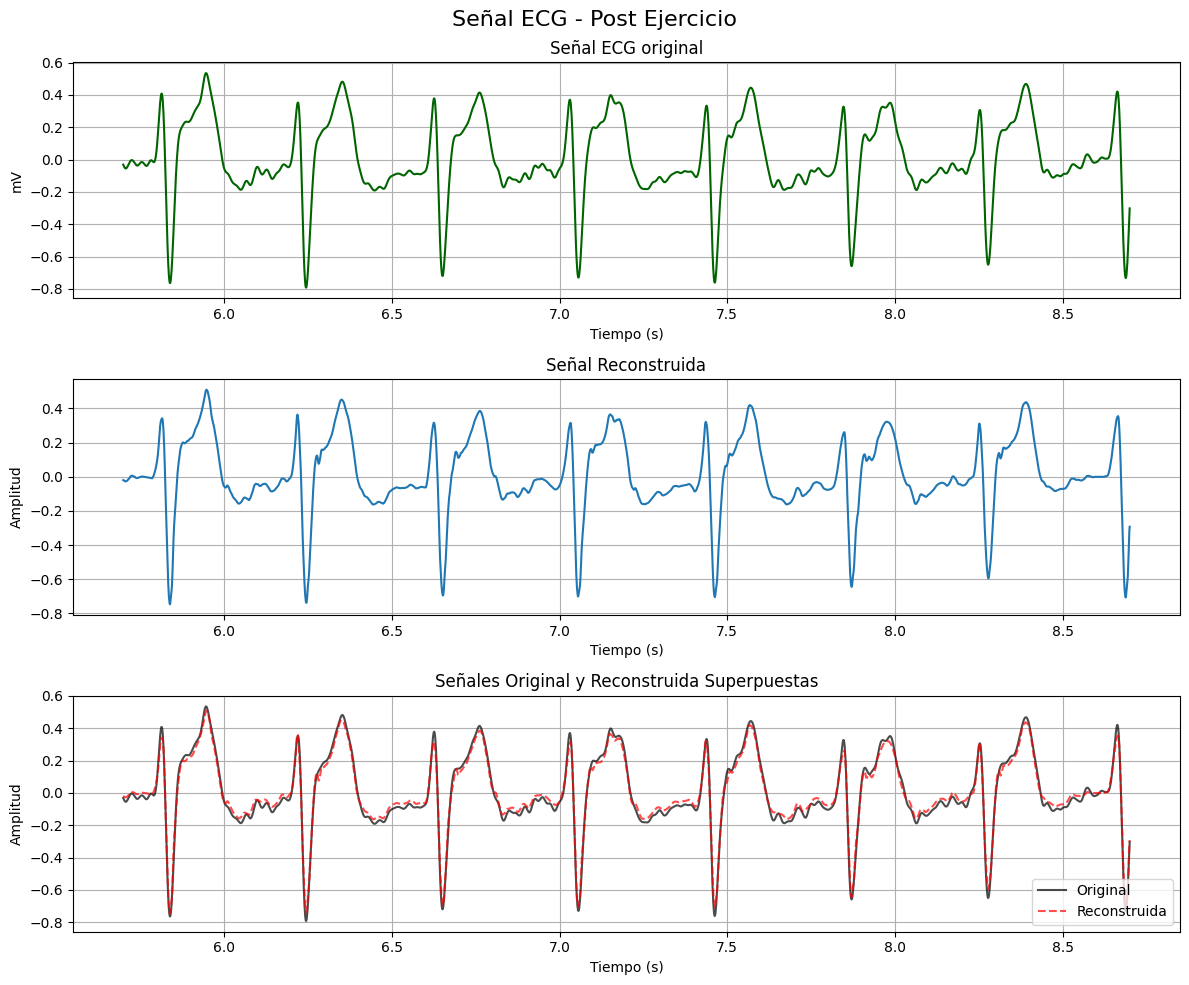

In [6]:
plt.figure(figsize=(12, 10))
plt.suptitle("Señal ECG - Post Ejercicio", fontsize=16)

# 1) Señal ECG original (post ejercicio)
plt.subplot(3, 1, 1)
plt.plot(t, x_filt, color="darkgreen")
plt.title("Señal ECG original")
plt.xlabel('Tiempo (s)')
plt.ylabel("mV"); plt.grid(True)

# 2) Graficar la señal reconstruida
plt.subplot(3, 1, 2)  # 3 filas, 1 columna, segundo subplot
plt.plot(t, x_rec)
plt.title('Señal Reconstruida')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud'); plt.grid(True)

# 3) Graficar ambas señales superpuestas
plt.subplot(3, 1, 3)  # 3 filas, 1 columna, tercer subplot
plt.plot(t, x_filt, label='Original', alpha=0.7, color="black")
plt.plot(t, x_rec, "--", label='Reconstruida', alpha=0.7, color="red")
plt.title('Señales Original y Reconstruida Superpuestas')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud'); plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

#### **Señal ECG - Reposo**

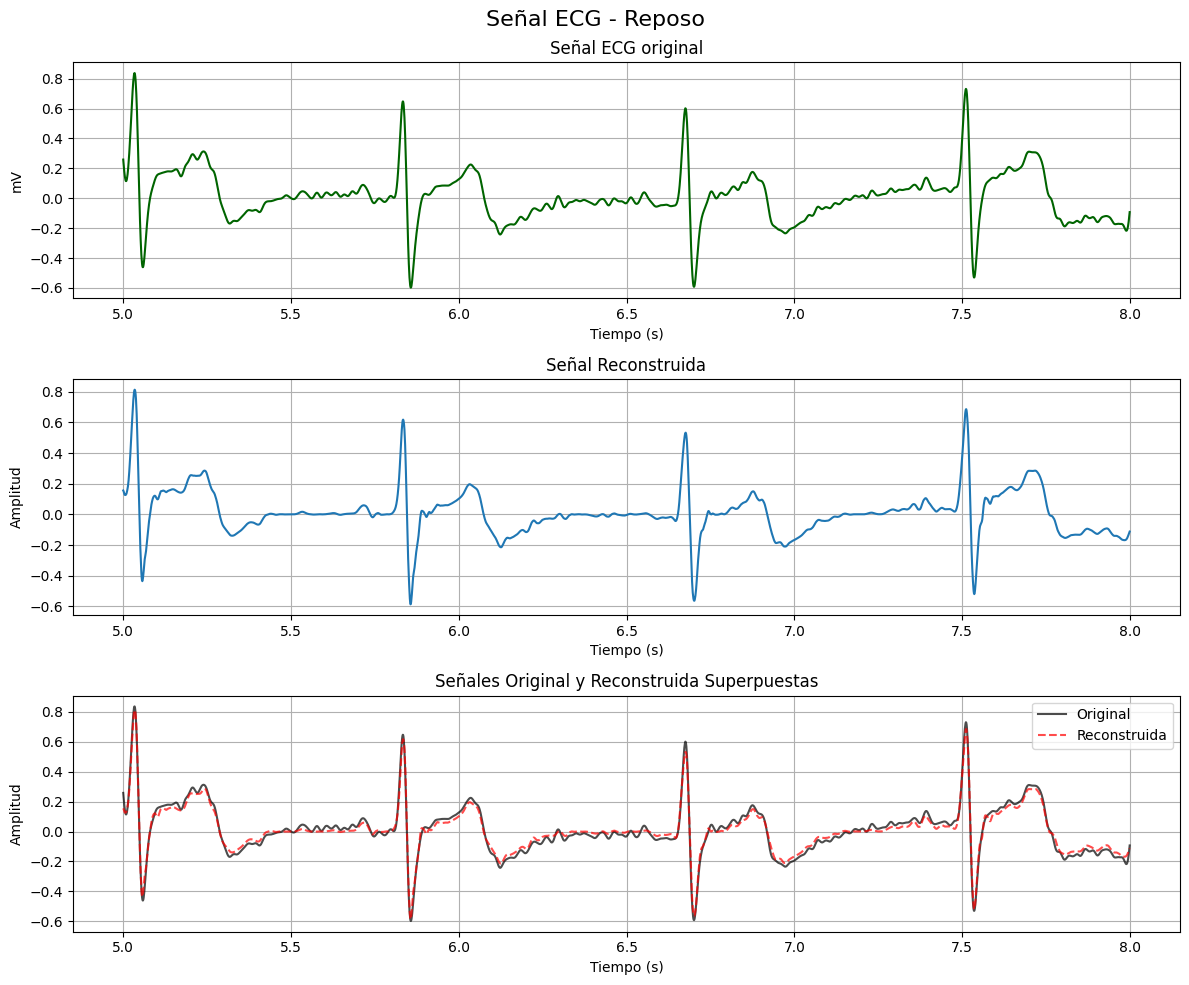

In [7]:
plt.figure(figsize=(12, 10))
plt.suptitle("Señal ECG - Reposo", fontsize=16)

# 1) Señal ECG original (reposo)
plt.subplot(3, 1, 1)
plt.plot(t2, x2_filt, color="darkgreen")
plt.title("Señal ECG original")
plt.xlabel('Tiempo (s)')
plt.ylabel("mV"); plt.grid(True)

# 2) Graficar la señal reconstruida
plt.subplot(3, 1, 2)  # 3 filas, 1 columna, segundo subplot
plt.plot(t2, x_rec2)
plt.title('Señal Reconstruida')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud'); plt.grid(True)

# 3) Graficar ambas señales superpuestas
plt.subplot(3, 1, 3)  # 3 filas, 1 columna, tercer subplot
plt.plot(t2, x2_filt, label='Original', alpha=0.7, color="black")
plt.plot(t2, x_rec2, "--", label='Reconstruida', alpha=0.7, color="red")
plt.title('Señales Original y Reconstruida Superpuestas')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud'); plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### **Calcular la STFT con parámetros ajustados**

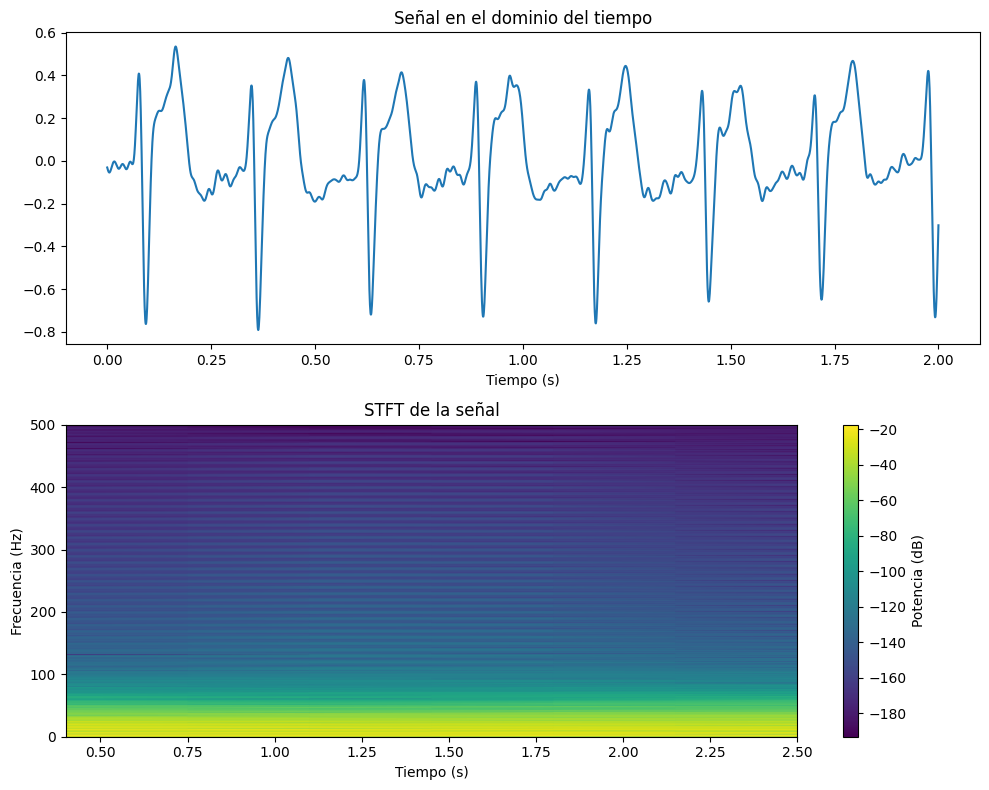

In [8]:
# Calcular la STFT con parámetros ajustados
frequencies, times, Sxx = spectrogram(x_filt, fs=1000, nperseg=800)

# Graficar la señal en el dominio del tiempo y su STFT
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(np.linspace(0, 2, len(x_filt)), x_filt)
plt.title('Señal en el dominio del tiempo')
plt.xlabel('Tiempo (s)')

plt.subplot(2, 1, 2)
plt.pcolormesh(times, frequencies, 10 * np.log10(Sxx), shading='gouraud')
plt.title('STFT de la señal')
plt.ylabel('Frecuencia (Hz)')
plt.xlabel('Tiempo (s)')
plt.colorbar(label='Potencia (dB)')

plt.tight_layout()
plt.show()